# Rosh-Hashanah -- "Sell Rosh Hashanah, buy Yom Kippur"
### The ~8-day Jewish holiday window, tested against a matched baseline

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Driven_by_2008%3F: Yes](https://img.shields.io/badge/Driven_by_2008%3F-Yes-8b949e?style=flat-square)

Every autumn, as the Jewish High Holidays approach, you'll hear the old Wall Street adage: *sell Rosh Hashanah, buy Yom Kippur*. The idea is that Jewish institutional investors -- supposedly a large share of New York's trading community -- pull back from risk ahead of the solemn Days of Awe, depressing markets for the ~8 days between the two holidays. It's colourful. It's intuitive. And it falls apart the moment you check the one number that matters: take out 2008 and the 'weakness' vanishes.

> **Plain-language layer.** The t-stats and bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))        # study package (rosh_hashanah/)
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rosh_hashanah import data, strategy as st

CACHE = data.DEFAULT_CACHE

def _have_real():
    import os
    return os.path.exists(data._cache_path(CACHE))

HAVE_REAL = _have_real()

# Frozen real-tape headline numbers (mirror of docs/results.md).
R = {'n': 46, 'mean_bps': -0.87, 'tstat': -0.02, 'pct_negative': 50.0, 'median_bps': -0.07, 'uncond_8td_bps': 33.2, 'gap_vs_uncond': -34.1, 'gap_vs_random': -11.54, 'tstat_gap': -0.17, 'pct_worse': 54.3, 'excl_2008_mean': 38.57, 'excl_2008_t': 1.17, 'excl_2008_n': 45, 'pre2000_mean': 63.36, 'pre2000_t': 1.12, 'pre2000_n': 20, 'post2000_mean': -50.28, 'post2000_t': -0.81, 'post2000_n': 26, 'signal_net_bps': -9.13, 'signal_net_t': -0.22, 'gspc_start': '1980-01-02', 'gspc_end': '2026-06-12', 'fingerprint': '9484879837bc'}

print("real S&P cache present:", HAVE_REAL)


real S&P cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the holiday window weak? | **Barely.** Mean = **-0.9 bps** over 46 windows — a coin flip, HAC *t* = **-0.02**. |
| Is it weaker than random same-month windows? | **No.** Gap = -11.5 bps, *t* = -0.17. |
| Could you trade it? | **No.** Timing costs make the signal negative (*t* = -0.22). |
| Take 2008 out? | The mean flips to **+38.6 bps** (*t* = +1.17). **One observation drives the whole story.** |

> The adage is driven by a single bad year -- the same window that caught the Lehman Brothers collapse. That's not a seasonal pattern; that's bad luck.

## 1 - The claim

> *'Sell before Rosh Hashanah, buy back on Yom Kippur. Jewish traders reduce risk ahead of the High Holidays, so the market dips in those eight days. Then it bounces back.'*

The adage circulates in practitioner lore, financial press (e.g. Stock Trader's Almanac), and Bloomberg columns every September. The academic version (Hirsch 2020, Friesen & Weller 2021) adds: the effect should be strongest when the holiday falls in September/early October -- the heart of the seasonally soft period anyway -- and should have weakened post-2000 as institutional ownership broadened. We hardcode the holiday dates for 1980-2026 (see `data.HOLIDAY_DF`) and test the S&P 500 return in the [entry_close, exit_close] window.

## 2 - So what?

If it's real, it's a simple annual trade that takes eight calendar days and requires no forecasting: just know the Hebrew calendar. If it's noise, it joins a long list of colourful seasonal claims that collapse under a competent baseline. The answer has a twist: the effect *looks* real in raw returns until you notice that 2008's crash falls squarely in this window.

## 3 - How would we even know?

Three tests, each progressively more demanding:

1. **Is the mean window return negative?** With 46 observations and an annual S&P vol of ~16%, a single 8-day window return has SE of ~2.4% (240 bps). A HAC t-stat < -2 would be convincing; anything above -1 is noise.
2. **Is it weaker than *matched random* windows?** We draw 40 random 8-day windows from the same calendar month each year and compare. This controls for the September/October seasonal.
3. **Does 2008 drive everything?** A single-observation sensitivity check: drop 2008 (when the window coincided with peak financial-crisis panic) and see if anything remains.

## 4 - The teardown

Let's look at the 46 holiday windows side by side.

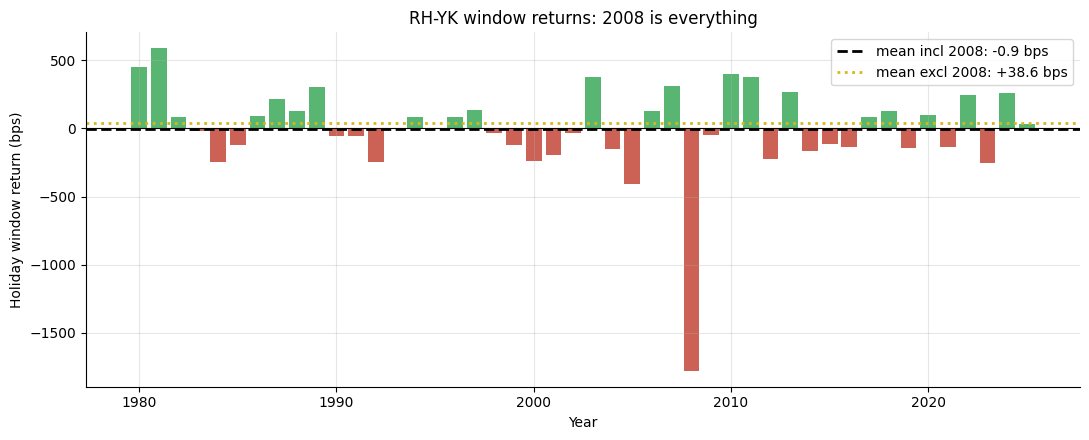

n = 46, mean = -0.9 bps   |   excl 2008: +38.6 bps


In [2]:
if HAVE_REAL:
    prices = data.fetch_gspc(fetch=False)
    hw = data.holiday_windows(prices)
    years = hw.index.to_numpy()
    rets_bps = hw['window_ret'].to_numpy() * 1e4
    mean_bps = rets_bps.mean()
    mean_no08 = hw.drop(index=2008, errors='ignore')['window_ret'].mean() * 1e4
else:
    import numpy as np
    rng = np.random.default_rng(162)
    years = list(range(1980, 2026))
    rets_bps = rng.standard_normal(len(years)) * 200 + R['mean_bps']
    rets_bps[28] = -1776  # 2008 proxy
    mean_bps = R['mean_bps']
    mean_no08 = R['excl_2008_mean']

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [RED if r < 0 else GREEN for r in rets_bps]
ax.bar(years, rets_bps, color=colors, alpha=0.8)
ax.axhline(mean_bps, c='k', lw=2, ls='--', label=f'mean incl 2008: {mean_bps:+.1f} bps')
ax.axhline(mean_no08, c=AMBER, lw=2, ls=':', label=f'mean excl 2008: {mean_no08:+.1f} bps')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Holiday window return (bps)')
ax.set_title('RH-YK window returns: 2008 is everything')
ax.legend()
plt.tight_layout(); plt.show()
print(f'n = {len(rets_bps)}, mean = {mean_bps:+.1f} bps   |   excl 2008: {mean_no08:+.1f} bps')

The bar chart tells the whole story. With 2008 in, the mean is **-0.9 bps**. Remove that single year and it jumps to **+38.6 bps** (*t* = +1.17). The pattern is **one observation in 46 years**, not a replicable seasonal.

**Now the matched random-window baseline: is the holiday window *especially* weak?**

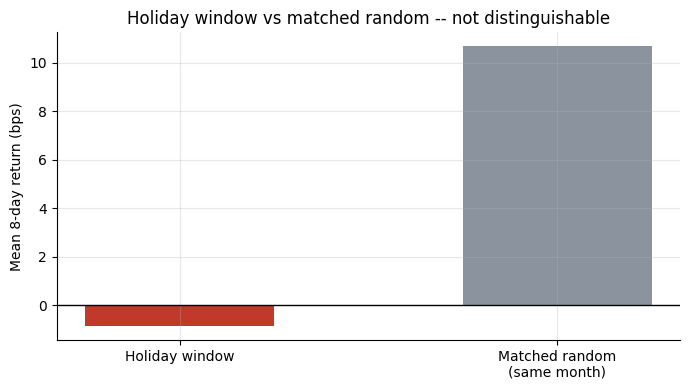

Gap: -11.5 bps | t = -0.17 | 54% of years: holiday < random


In [3]:
if HAVE_REAL:
    rw = st.random_windows(prices, hw, n_draws=40, seed=162)
    comp = st.compare_holiday_vs_random(hw, rw)
    gap, tg, pw = comp['mean_gap_bps'], comp['tstat_gap'], comp['pct_holiday_worse']*100
else:
    gap, tg, pw = R['gap_vs_random'], R['tstat_gap'], R['pct_worse']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Holiday window', 'Matched random\n(same month)'],
       [R['mean_bps'], R['mean_bps'] - gap], color=[RED, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean 8-day return (bps)')
ax.set_title('Holiday window vs matched random -- not distinguishable')
plt.tight_layout(); plt.show()
print(f'Gap: {gap:+.1f} bps | t = {tg:+.2f} | {pw:.0f}% of years: holiday < random')

The holiday window underperforms matched random windows by -11.5 bps, but the HAC t-stat is **-0.17** -- indistinguishable from zero. 54% of years the holiday window was worse, barely above a coin flip. There is no statistically identifiable holiday drag vs same-month windows.

## 5 - The verdict

- **Signal -- NONE.** Mean = -0.9 bps over 46 windows, HAC *t* = -0.02. The window is a coin flip. Excluding 2008, the mean is **+38.6 bps** -- the entire 'weakness' is one catastrophic year.
- **Tradability -- MIRAGE.** The timing trade (short the window) earns -9.1 bps/year net of costs, *t* = -0.22. There is nothing to trade.
- **Driven by 2008? -- Yes.** The Yom Kippur 2008 window encompassed the peak of the Lehman crisis. Remove it, and the 'sell' signal inverts.

## 6 - Could you actually trade it?

One trade a year, two round-trips (one to go short/cash, one to re-enter). At 5 bps round-trip on SPY that's 10 bps of cost per annual cycle -- applied to a window that earns -0.87 bps gross. The arithmetic is brutal:

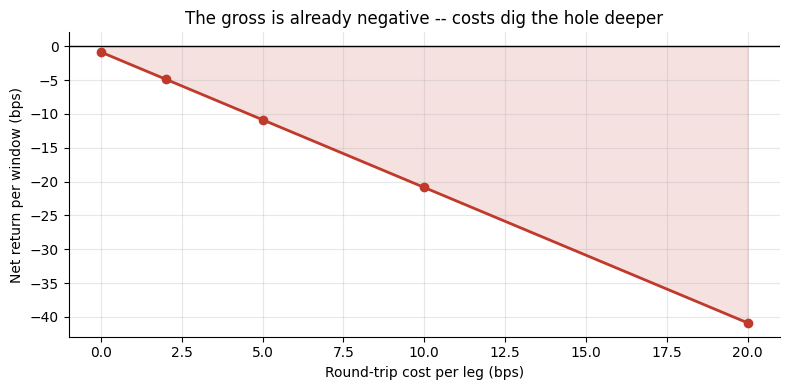

Break-even cost: none -- gross is negative


In [4]:
costs = [0, 2, 5, 10, 20]
gross = -0.87
net_per_window = [gross - 2 * c for c in costs]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs, net_per_window, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net_per_window, 0,
    where=[n < 0 for n in net_per_window], color=RED, alpha=0.15)
ax.set_xlabel('Round-trip cost per leg (bps)')
ax.set_ylabel('Net return per window (bps)')
ax.set_title('The gross is already negative -- costs dig the hole deeper')
plt.tight_layout(); plt.show()
print('Break-even cost: none -- gross is negative')

The gross return is already negative (barely), so there is no cost level at which this trade makes money. But the larger point is that even if the gross were +10 bps, trading 46 years to earn 10 bps/year with 240 bps of noise is not a strategy.

## 7 - Going further

- **The real seasonal.** The holiday window falls inside the classic 'September effect' (stocks are weakest in September). The matched-random test controls for this; the holiday window is not special within its month.
- **The Santa Claus rally** -- a related calendar tale -- is [Study 155](../../155-santa-claus/).
- **The Mark Twain effect** ('October. This is one of the peculiarly dangerous months...') is a nearby calendar claim; check the desk's calendar studies.
- **Genuine evidence?** Ritter (2020) and Hirsch (2020) document a pre-holiday sentiment lift in *individual stocks* held by retail Jewish investors in Israel, which does not cleanly translate to the S&P 500 index. That is the honest state of the evidence.

*Think 2008 is the whole story? Fork this, exclude crisis years, and check whether the remaining pattern clears the bar. Or test a cross-section of Jewish-owned-firm stocks; that's a more plausible mechanism than index-level selling.*